# 제조 AI 6주차


## STEP 0 
```text
Manufacturing_AI_Project/
├── 제조AI_1주차.ipynb
├── 제조AI_6주차.ipynb
└── CMAPSSData
    ├── 6. Turbofan Engine Degradation Simulation Data Set
    ├── CMAPSSData.zip
    ├── Damage Propagation Modeling.pdf
    ├── readme.txt
    ├── RUL_FD001.txt
    ├── RUL_FD002.txt
    ├── RUL_FD003.txt
    ├── RUL_FD004.txt
    ├── test_FD001.txt
    ├── test_FD002.txt
    ├── test_FD003.txt
    ├── test_FD004.txt
    ├── train_FD001.txt
    ├── train_FD002.txt
    ├── train_FD003.txt
    └── train_FD004.txt
```

In [1]:
import pandas as pd
import numpy as np
import koreanize_matplotlib
import matplotlib.pyplot as plt

# C-MAPSS 데이터가 저장된 폴더
DATA_DIR = './CMAPSSData'

# FD001 학습 데이터 파일 경로
train_path = f'{DATA_DIR}/train_FD001.txt'


# 데이터의 열 이름 정의
# unit  : 엔진 번호
# cycle : 엔진의 운전 사이클
# set1 ~ set3 : 운전 조건(Operating Settings)
# s1 ~ s21    : 21개의 센서 측정값
cols = (
    ['unit', 'cycle']
    + [f'set{i}' for i in range(1, 4)]
    + [f's{i}' for i in range(1, 22)]
)
# FD001 학습 데이터 불러오기
df = pd.read_csv(
    train_path,
    sep=r'\s+',      # 공백을 기준으로 데이터 구분
    header=None,     # 원본 파일에는 열 이름이 없음
    names=cols       # 위에서 정의한 열 이름 사용
)


# 데이터 크기 확인
print('데이터 크기:', df.shape)

# 전체 엔진 수 확인
print('엔진 수:', df['unit'].nunique())

# 데이터의 처음 5개 행 확인
df.head(10)

데이터 크기: (20631, 26)
엔진 수: 100


,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [2]:
# 각 시점에서 엔진의 잔여수명(RUL: Remaining Useful Life) 계산
# RUL = 엔진의 마지막 cycle - 현재 cycle
df['RUL'] = (
    df.groupby('unit')['cycle'].transform('max')
    - df['cycle']
)

# RUL의 최대값을 125로 제한
# df['RUL'] = df['RUL'].clip(upper=125)


# 1번 엔진의 일부 시점에서 cycle과 RUL 확인
df[df['unit'] == 1][['cycle', 'RUL']].iloc[[0, 50, 100, -1]]

,cycle,RUL
0,1,191
50,51,141
100,101,91
191,192,0


## STEP 1

In [3]:
# 사용할 센서 열 정의 (s1 ~ s21)
sensor_cols = [f's{i}' for i in range(1, 22)]


# 전체 100대의 엔진 중 1~80번 엔진을 학습 데이터로 사용
train_units = df['unit'].unique()[:80]

# 정상적인 학습 데이터만 선택 (RUL이 100 이상인 데이터)
normal = df[(df.unit.isin(train_units)) & (df.RUL >= 100)]
print('정상 학습 데이터:', len(normal), '행  (각 엔진의 앞쪽 인생만)')


정상 학습 데이터: 8138 행  (각 엔진의 앞쪽 인생만)


In [4]:
# 학습 데이터에서 각 센서의 표준편차 계산
std_n = normal[sensor_cols].std()

# 표준편차가 거의 0인 센서(값의 변화가 없는 센서) 제거
use_cols = std_n[std_n > 1e-6].index.tolist()

print('사용 센서:', len(use_cols), '개')
print(use_cols)

# 학습 데이터에서 각 센서의 평균과 표준편차 계산
mu = normal[use_cols].mean()
sd = normal[use_cols].std()


Xn = ((normal[use_cols] - mu) / sd).values.astype('float32')
df_s = df.copy()
df_s[use_cols] = (df[use_cols] - mu) / sd          # 전체는 같은 자로
print('Xn:', Xn.shape, '| 사용 센서', len(use_cols), '개')

사용 센서: 15 개
['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Xn: (8138, 15) | 사용 센서 15 개


## STEP 2

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 입력 센서 데이터를 복원하는 오토인코더 모델
autoencoder = models.Sequential([
    # 입력층: 사용 센서 수만큼 값을 입력받아 8개 뉴런으로 압축
    layers.Dense(8, activation='relu', input_shape=(len(use_cols),)),

    # 은닉층: 데이터를 4차원 표현으로 더 압축 (Latent Space)
    layers.Dense(4, activation='relu'),

    # 복원층: 압축된 표현을 다시 8차원으로 확장
    layers.Dense(8, activation='relu'),

    # 출력층: 입력 센서 수와 같은 차원으로 복원
    layers.Dense(len(use_cols))
])

# 입력과 복원 결과의 평균제곱오차(MSE)를 줄이도록 학습
autoencoder.compile(optimizer='adam', loss='mse')

# 모델의 층과 파라미터 수 확인
autoencoder.summary()

/opt/miniconda3/envs/ManufactoringAI/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339 (1.32 KB)

 Trainable params: 339 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# fit(Xn, Xn) — 정답은 입력 자신: 자기 지도 학습의 실물
history_autoencoder = autoencoder.fit(Xn, Xn, validation_split=0.1, epochs=30, batch_size=256, verbose=2)

Epoch 1/30
29/29 - 1s - 18ms/step - loss: 0.9868 - val_loss: 1.2360
Epoch 2/30
29/29 - 0s - 1ms/step - loss: 0.9378 - val_loss: 1.1777
Epoch 3/30
29/29 - 0s - 1ms/step - loss: 0.8679 - val_loss: 1.0448
Epoch 4/30
29/29 - 0s - 1ms/step - loss: 0.7596 - val_loss: 0.8876
Epoch 5/30
29/29 - 0s - 1ms/step - loss: 0.6706 - val_loss: 0.7893
Epoch 6/30
29/29 - 0s - 1ms/step - loss: 0.6169 - val_loss: 0.7281
Epoch 7/30
29/29 - 0s - 1ms/step - loss: 0.5833 - val_loss: 0.6837
Epoch 8/30
29/29 - 0s - 2ms/step - loss: 0.5595 - val_loss: 0.6497
Epoch 9/30
29/29 - 0s - 2ms/step - loss: 0.5404 - val_loss: 0.6214
Epoch 10/30
29/29 - 0s - 1ms/step - loss: 0.5238 - val_loss: 0.5983
Epoch 11/30
29/29 - 0s - 1ms/step - loss: 0.5083 - val_loss: 0.5770
Epoch 12/30
29/29 - 0s - 1ms/step - loss: 0.4926 - val_loss: 0.5568
Epoch 13/30
29/29 - 0s - 1ms/step - loss: 0.4778 - val_loss: 0.5372
Epoch 14/30
29/29 - 0s - 1ms/step - loss: 0.4636 - val_loss: 0.5190
Epoch 15/30
29/29 - 0s - 1ms/step - loss: 0.4505 - val_l

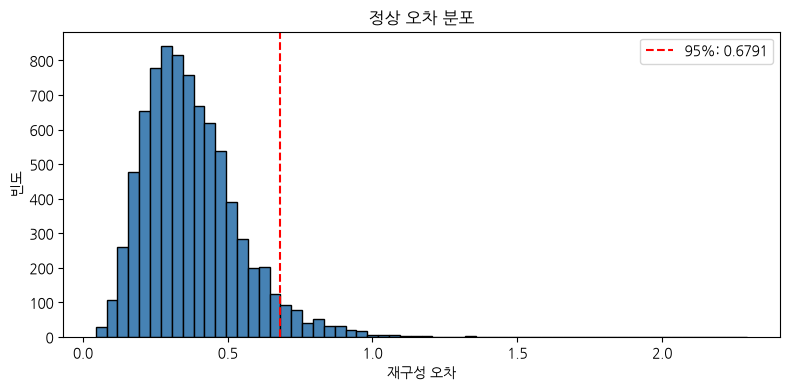

퍼센타일 [50, 95, 99]: [0.35, 0.6791, 0.8908]


In [7]:
# 입력 데이터와 오토인코더의 복원 결과를 비교해 행별 평균제곱오차(MSE)를 계산
def compute_reconstruction_error(model, data):
    recon = model.predict(data, verbose=0)       # 입력 데이터를 복원
    err = ((data - recon) ** 2).mean(axis=1)    # 각 행의 센서별 오차 평균
    return recon, err


# 정상 학습 데이터(Xn)의 복원 결과와 오차 계산
recon, err_n = compute_reconstruction_error(autoencoder, Xn)

# 정상 오차의 주요 백분위수 확인
q50, q95, q99 = np.percentile(err_n, [50, 95, 99])

# 정상 데이터의 오차 분포와 95백분위수 표시
plt.figure(figsize=(8, 4))
plt.hist(err_n, bins=60, color='steelblue', edgecolor='black')
plt.axvline(q95, color='red', linestyle='--', linewidth=1.5, label=f'95%: {q95:.4f}')
plt.xlabel('재구성 오차')
plt.ylabel('빈도')
plt.title('정상 오차 분포')
plt.legend()
plt.tight_layout()
plt.show()

# 백분위수 값을 소수점 넷째 자리까지 출력
print(f'퍼센타일 [50, 95, 99]: {np.round([q50, q95, q99], 4).tolist()}')

In [8]:
# 정상 학습 데이터의 재구성 오차 95백분위수를 이상 감지 임계값으로 설정
# 학습 데이터 기준으로 약 5%의 관측치가 임계값을 초과할 수 있음
TH = float(np.percentile(err_n, 95))

print(f'이상 감지 임계값 (정상 오차 95백분위수): {TH:.4f}')

이상 감지 임계값 (정상 오차 95백분위수): 0.6791


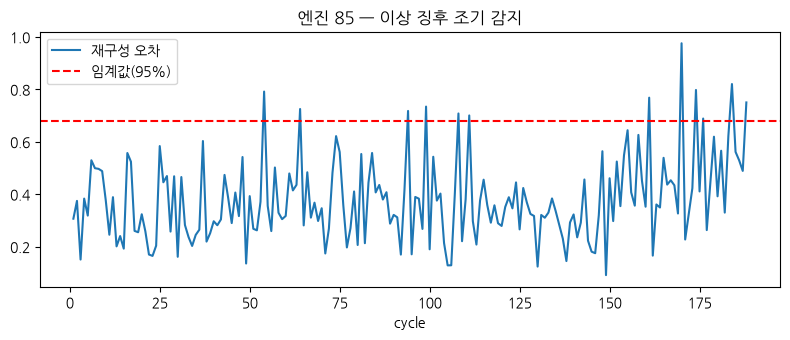

In [9]:
# 확인할 엔진 번호
u = 85

# 엔진 데이터와 사이클별 재구성 오차 계산
g = df_s.loc[df_s['unit'].eq(u)]
X = g[use_cols].to_numpy(dtype='float32')
recon_u = autoencoder.predict(X, verbose=0)
err_u = np.mean((X - recon_u) ** 2, axis=1)

# 재구성 오차와 임계값 시각화
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(g['cycle'], err_u, label='재구성 오차')
ax.axhline(TH, color='red', linestyle='--', label='임계값(95%)')
ax.set(xlabel='cycle', title=f'엔진 {u} — 이상 징후 조기 감지')
ax.legend()
fig.tight_layout()
plt.show()


감지: 11/20대 | 평균 리드타임: 31 사이클


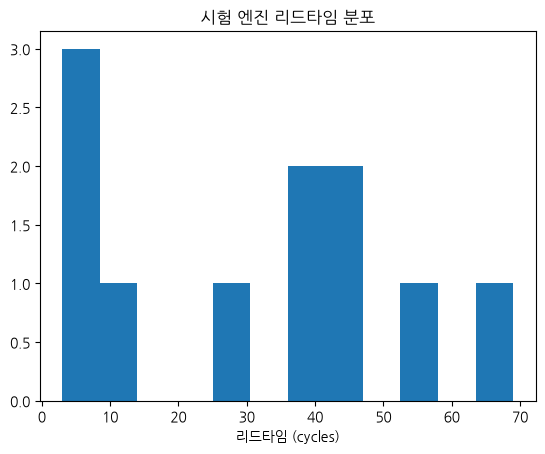

In [ ]:
# # 테스트 엔진 목록: 학습에 사용하지 않은 엔진만 선택
test_units = [u for u in df['unit'].unique() if u not in train_units]


# 특정 엔진의 재구성 오차를 계산하는 함수
# - g: 엔진의 데이터 프레임
# - X_u: 해당 엔진의 표준화된 센서 입력
# - recon_u: 오토인코더가 복원한 결과
# - err: 각 사이클별 재구성 오차
def unit_err(u):
    g = df_s.loc[df_s['unit'].eq(u)].sort_values('cycle')
    X_u = g[use_cols].to_numpy(dtype='float32')
    recon_u = autoencoder.predict(X_u, verbose=0)
    err = np.mean((X_u - recon_u) ** 2, axis=1)
    return g, err

# 리드타임 계산 함수
# - 연속 k개 시점이 모두 임계값(th)보다 큰 첫 구간을 찾음
# - 해당 구간 시작 시점으로부터 마지막 사이클까지 남은 기간이 리드타임
# - 즉, "임계값 초과가 처음 시작된 시점"부터 "고장까지 남은 사이클 수"
def lead_time(u, th=TH, k=3):
    g, err = unit_err(u)
    over = err > th

    # 연속 k회 이상 임계값을 초과하는 구간을 탐색
    for i in range(len(over) - k + 1):
        if over[i:i + k].all():
            # 마지막 cycle - 초과 시작 cycle
            # => 해당 시점에서 고장까지 남은 사이클 수
            return int(g['cycle'].iloc[-1] - g['cycle'].iloc[i])

    return None  # 감지되지 않은 경우 None 반환

# 모든 테스트 엔진에 대해 리드타임 계산
leads = [lead_time(u) for u in test_units]
det = [lead for lead in leads if lead is not None]

# 감지된 엔진 수와 평균 리드타임 출력
mean_lead = f'{np.mean(det):.0f}' if det else '-'
print(f'감지: {len(det)}/{len(test_units)}대 | 평균 리드타임: {mean_lead} 사이클')

# 감지된 엔진이 있으면 리드타임 분포 히스토그램 시각화
if det:
    plt.hist(det, bins=12)
    plt.xlabel('리드타임 (cycles)')
    plt.title('시험 엔진 리드타임 분포')
    plt.show()

In [11]:
# 정상 데이터에서 임계값을 초과한 비율(오탐률)을 계산
def normal_fp_rate(threshold):
    return float((err_n > threshold).mean())


# 특정 백분위 임계값의 감지 결과를 계산
def evaluate_threshold_sensitivity(percentile):
    threshold = float(np.percentile(err_n, percentile))

    # 테스트 엔진별 리드타임을 계산하고, 감지된 엔진만 추림
    lead_times = [lead_time(unit, th=threshold) for unit in test_units]
    detected_lead_times = [
        value for value in lead_times if value is not None
    ]

    # 감지된 엔진이 없으면 평균 리드타임을 '-'로 표시
    mean_lead_time = (
        f'{np.mean(detected_lead_times):.0f}'
        if detected_lead_times else '-'
    )

    return {
        'detected_count': len(detected_lead_times),
        'mean_lead_time': mean_lead_time,
        'false_positive_rate': normal_fp_rate(threshold),
    }


# 임계값 백분위수에 따른 감지율·리드타임·오탐률 비교
for threshold_percentile in [95, 99, 99.9]:
    result = evaluate_threshold_sensitivity(threshold_percentile)

    print(
        f'{threshold_percentile:>5}% | '
        f'감지 {result["detected_count"]:>2}/{len(test_units)}대 | '
        f'평균 리드타임 {result["mean_lead_time"]:>4} | '
        f'정상 오탐률 {result["false_positive_rate"] * 100:.2f}%'
    )

# 감지율 · 리드타임 · 오탐률은 서로 영향을 주는 지표

   95% | 감지 11/20대 | 평균 리드타임   31 | 정상 오탐률 5.00%
   99% | 감지  7/20대 | 평균 리드타임   28 | 정상 오탐률 1.01%
 99.9% | 감지  6/20대 | 평균 리드타임   23 | 정상 오탐률 0.11%


# 과제

### 1.임계값 (95, 99, 99.5, 99.9 백분위수) 변경에 따른 이상 감지 결과 비교




| 임계값(퍼센타일) | 감지 대수 / 20 | 평균 리드타임 | 정상 오탐률 |
|:---:|:---:|:---:|:---:|
| 95% |  |  |  |
| 99%  |  |  |  |
| 99.5%  |  |  |  |
| 99.9%  |  |  |  |

### 2. 정상 오탐률 vs 평균 리드타임 산점도